TITRE

INTRODUCTION

SOMMAIRE

Installation

In [19]:
!pip install -r requirements.txt
#Modules:
import geopandas as gpd
import pandas as pd
#Fonctions:
import src.clear_data as cd
import src.get_data as gd
import seaborn as sns
import matplotlib.pyplot as plt

Préparation des données

Adresses

In [2]:
url_metro = "https://data.rennesmetropole.fr/explore/dataset/topologie-des-points-darret-de-metro-du-reseau-star/download/?format=geojson"

url_dvf = "https://files.data.gouv.fr/geo-dvf/latest/csv/2023/full.csv.gz"

Import et modifications/nettoyage des données

In [3]:
#Import
df_dvf_raw = gd.fetch_dvf_api()
gdf_metro_raw = gd.fetch_metro_api()
#Nettoyage
gdf_metro = cd.clean_metro_data(gdf_metro_raw)
gdf_dvf = cd.clean_dvf_data(df_dvf_raw)
#Base fusionnée
gdf_final = cd.merge_dvf_by_line(gdf_dvf, gdf_metro)
gdf_final['prix_m2'] = gdf_final['valeur_fonciere'] / gdf_final['surface_reelle_bati']
print(gdf_final.head)
print(gdf_final.columns)

--- Récupération DVF (Source miroir stable) ---


/home/onyxia/work/Projet-python-pour-la-data-science/src/get_data.py:52: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_rennes = pd.concat(df_rennes_list)


--- Récupération des données Métro via API (Rennes Métropole) ---
<bound method NDFrame.head of         date_mutation nature_mutation  valeur_fonciere code_commune  \
1365203    2023-01-04           Vente         160000.0        35238   
1365206    2023-01-07           Vente         320000.0        35238   
1365214    2023-01-06           Vente         120000.0        35238   
1365215    2023-01-06           Vente         120000.0        35238   
1365243    2023-01-04           Vente         310000.0        35238   
...               ...             ...              ...          ...   
1428108    2023-12-22           Vente         151480.0        35238   
1428170    2023-12-19           Vente         156000.0        35051   
1428292    2023-11-17           Vente         263000.0        35238   
1428428    2023-11-14           Vente         270000.0        35238   
1428450    2023-08-30           Vente         250000.0        35238   

            nom_commune   type_local  surface_reell

Statistiques Descriptives 

In [4]:
print(gdf_final.head)

<bound method NDFrame.head of         date_mutation nature_mutation  valeur_fonciere code_commune  \
1365203    2023-01-04           Vente         160000.0        35238   
1365206    2023-01-07           Vente         320000.0        35238   
1365214    2023-01-06           Vente         120000.0        35238   
1365215    2023-01-06           Vente         120000.0        35238   
1365243    2023-01-04           Vente         310000.0        35238   
...               ...             ...              ...          ...   
1428108    2023-12-22           Vente         151480.0        35238   
1428170    2023-12-19           Vente         156000.0        35051   
1428292    2023-11-17           Vente         263000.0        35238   
1428428    2023-11-14           Vente         270000.0        35238   
1428450    2023-08-30           Vente         250000.0        35238   

            nom_commune   type_local  surface_reelle_bati  \
1365203          Rennes  Appartement                 65.

In [5]:
print(gdf_final.columns)

Index(['date_mutation', 'nature_mutation', 'valeur_fonciere', 'code_commune',
       'nom_commune', 'type_local', 'surface_reelle_bati',
       'nombre_pieces_principales', 'surface_terrain', 'longitude', 'latitude',
       'geometry', 'station_A', 'dist_metro_A', 'station_B', 'dist_metro_B',
       'prix_m2'],
      dtype='object')


In [6]:
print(gdf_final.describe())

       valeur_fonciere  surface_reelle_bati  nombre_pieces_principales  \
count     4.074000e+03          4074.000000                4074.000000   
mean      3.329139e+05            63.762887                   2.984536   
std       5.896458e+05            35.331105                   1.515614   
min       1.000000e+00             1.000000                   0.000000   
25%       1.400000e+05            40.000000                   2.000000   
50%       2.042000e+05            61.000000                   3.000000   
75%       3.184875e+05            79.000000                   4.000000   
max       5.100000e+06           336.000000                  11.000000   

       surface_terrain    longitude     latitude  dist_metro_A  dist_metro_B  \
count       830.000000  4074.000000  4074.000000   4074.000000   4074.000000   
mean        362.486747    -1.673620    48.108543   1280.840403   1031.341449   
std         878.934266     0.024965     0.014713   1161.519640    813.525349   
min          

--- Statistiques Globales ---
count      4074.000000
mean       5944.516436
std       14605.175466
min           0.019231
25%        3056.372549
50%        3869.565217
75%        4824.561404
max      465585.000000
Name: prix_m2, dtype: float64

--- Comparaison par Ligne de Métro ---
                     mean       median           std  count
ligne_proche                                               
A             4667.938997  3701.190476   7889.740733   1974
B             7144.499228  4021.178844  18773.240661   2100

--- Statistique par tranche ---
  Tranche de distance  Prix moyen au m2 (€)  Nombre de ventes
0              < 250m           5270.147815               949
1         250m - 500m           4910.158363              1043
2         500m - 800m           4620.986342               790
3              > 800m           8084.144968              1292


/home/onyxia/work/Projet-python-pour-la-data-science/src/stats_desc.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


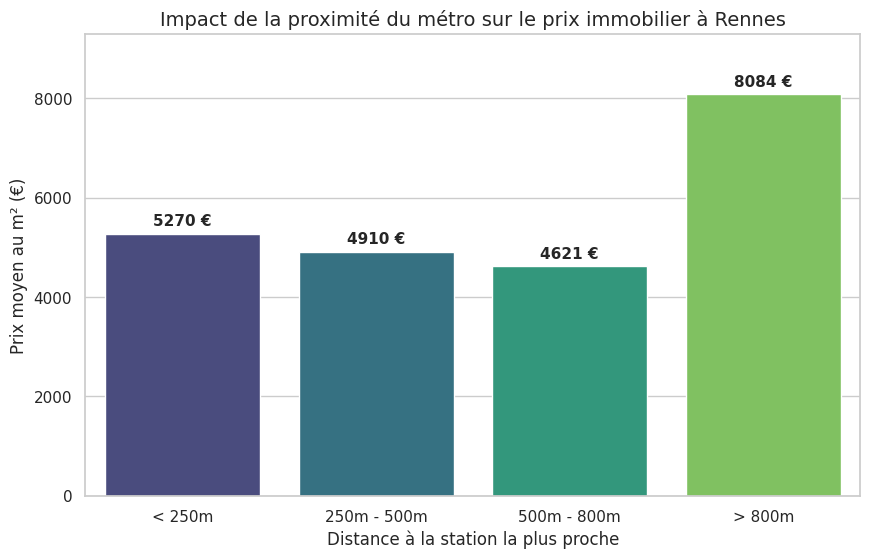


--- Statistique par variable de contrôle ---
proximite    Loin (>500m)  Proche (<500m)  Plus-value (%)
type_local                                               
Appartement   7212.648758     4984.903013      -30.886652
Maison        4986.947783     6132.156867       22.964128


In [ ]:
import src.stats_desc as sd

# Statistiques générales
print("--- Statistiques Globales ---")
print(sd.get_general_stats(gdf_final))

# Comparaison Ligne A vs Ligne B
print("\n--- Comparaison par Ligne de Métro ---")
stats_lignes = sd.get_stats_by_ligne(gdf_final)
print(stats_lignes)

# Statistique par tranche (distance min au métro <250, 250-500, 500-800, >800)
print("\n--- Statistique par tranche ---")
stats_tranches = sd.analyse_prix_dist_tranche(gdf_final)
print(stats_tranches)


#Graphique baton des statistiques par tranche
sd.plot_prix_par_tranche(stats_tranches)

# Statistique par variable de contrôle
print("\n--- Statistique par variable de contrôle ---")
var_control_type = sd.compare_proximity_controlled(gdf_final)
print(var_control_type)


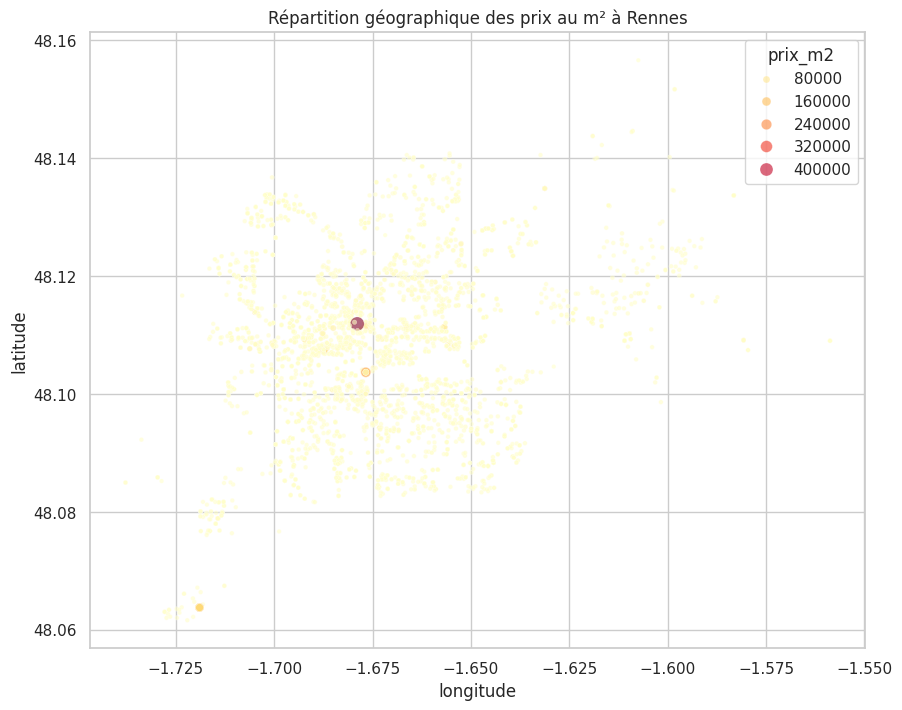

In [27]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=gdf_final, x="longitude", y="latitude", hue="prix_m2", 
                palette="YlOrRd", size="prix_m2", sizes=(10, 100), alpha=0.6)
plt.title("Répartition géographique des prix au m² à Rennes")
plt.show()

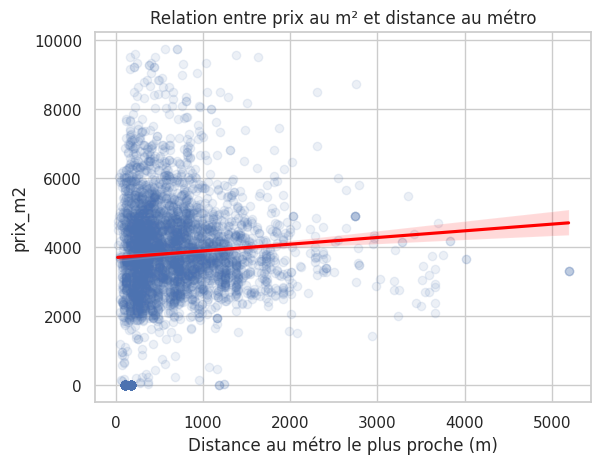

In [28]:
sns.regplot(data=gdf_final[gdf_final['prix_m2'] < 10000], 
            x="dist_min_metro", y="prix_m2", 
            scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title("Relation entre prix au m² et distance au métro")
plt.xlabel("Distance au métro le plus proche (m)")
plt.show()

DiD

In [8]:
df_ready = sd.prepare_did_data(gdf_final)
results = sd.run_did_regression(df_ready)
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                prix_m2   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     16.10
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           2.11e-10
Time:                        13:14:24   Log-Likelihood:                -44822.
No. Observations:                4074   AIC:                         8.965e+04
Df Residuals:                    4070   BIC:                         8.968e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [9]:
df_ready[['treated', 'post_event']].value_counts()

treated  post_event
0        1             3125
1        1              949
Name: count, dtype: int64

In [ ]:
# plot_did_trends(df_ready)